In [1]:
# ============================================================
# PIPELINE PROOF-OF-CONCEPT — All 8 Flows
# Install all dependencies (Kaggle free-tier compatible)
# Production models are noted inline; POC uses lighter equivalents
# ============================================================

# Core ML + vision
!pip install -q transformers>=4.45 accelerate qwen-vl-utils

# Whisper ASR  (prod: large-v3  →  POC: small)
!pip install -q openai-whisper

# SAM2 object segmentation  (prod: SAM3/hiera-large  →  POC: hiera-tiny)
!pip install -q 'git+https://github.com/facebookresearch/sam2.git'

# Demucs audio source separation  (same model in prod & POC)
!pip install -q demucs

# Stable Diffusion  (prod: Flux-dev/SD3  →  POC: SD-1.5)
!pip install -q diffusers

# Kokoro TTS  (prod: Orpheus-3B  →  POC: kokoro-onnx)
!pip install -q kokoro-onnx

# Utilities
!pip install -q soundfile opencv-python-headless Pillow requests

print("All packages installed.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 12.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 1.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 5.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 17.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.1/87.1 kB 6.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.6/59.6 kB 3.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) .

In [2]:
# ── Imports & GPU check ──────────────────────────────────────
import os, json, gc, time, hashlib, logging, shlex, subprocess, glob
import base64, tempfile, textwrap
from io import BytesIO
from dataclasses import dataclass, field
from typing import Literal, Optional
import torch
import numpy as np
import requests
from IPython.display import display, Audio, Image as IPImage
from PIL import Image

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s")
log = logging.getLogger("pipeline")

PIPELINE_LOG = "/kaggle/working/pipeline_log.jsonl"
os.makedirs("/kaggle/working/cache", exist_ok=True)

# — HF Token (optional: needed for gated models like Qwen/SAM2)
try:
    from kaggle_secrets import UserSecretsClient
    HF_TOKEN = UserSecretsClient().get_secret("HF_TOKEN")
    print(f"[Cell 2] HF_TOKEN loaded ({len(HF_TOKEN)} chars)")
except Exception as _hf_err:
    HF_TOKEN = None
    print(f"[Cell 2] HF_TOKEN not found ({_hf_err}) — open-weight models will still work")

Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB
[Cell 2] HF_TOKEN loaded (37 chars)


In [3]:
# ============================================================
# CELL 2.5 — resilient_download + Stage Registry + ModelManager
# P0: Prevents OOM; P1: Prevents network hangs
# ============================================================

MAX_DOWNLOAD_SIZES = {
    "image": 20 * 1024 * 1024,
    "video": 500 * 1024 * 1024,
    "audio": 100 * 1024 * 1024,
    "default": 200 * 1024 * 1024,
}

def resilient_download(url, dest, media_type="default", timeout=30, retries=3, backoff=2):
    """Download with retry/backoff, size guard, and streaming write."""
    max_size = MAX_DOWNLOAD_SIZES.get(media_type, MAX_DOWNLOAD_SIZES["default"])
    for attempt in range(retries):
        try:
            with requests.get(url, stream=True, timeout=timeout,
                              headers={"User-Agent": "Mozilla/5.0"}) as r:
                r.raise_for_status()
                content_length = int(r.headers.get("Content-Length", 0))
                if content_length and content_length > max_size:
                    raise ValueError(f"Content-Length {content_length} exceeds {max_size} byte limit")
                downloaded = 0
                with open(dest, "wb") as f:
                    for chunk in r.iter_content(65536):
                        downloaded += len(chunk)
                        if downloaded > max_size:
                            os.remove(dest)
                            raise ValueError(f"Download exceeded {max_size} bytes mid-stream")
                        f.write(chunk)
            return dest
        except (requests.Timeout, requests.ConnectionError) as e:
            log.warning(f"Download attempt {attempt+1}/{retries} failed: {e}")
            if attempt == retries - 1:
                raise
            time.sleep(backoff ** attempt)

# ── Stage Registry: change one string to swap a model ──────────────
# loader functions are defined lazily — they return the loaded model object
def load_vlm():
    from transformers import Qwen2VLForConditionalGeneration, AutoProcessor
    from qwen_vl_utils import process_vision_info
    proc = AutoProcessor.from_pretrained("Qwen/Qwen2-VL-2B-Instruct", trust_remote_code=True)
    mdl = Qwen2VLForConditionalGeneration.from_pretrained(
        "Qwen/Qwen2-VL-2B-Instruct",
        torch_dtype=torch.float16 if DEVICE == "cuda" else torch.float32,
        device_map="auto",
    )
    return {"model": mdl, "processor": proc, "process_vision_info": process_vision_info}

def load_asr():
    import whisper
    return {"model": whisper.load_model("small", device=DEVICE)}

def load_sam():
    from sam2.sam2_image_predictor import SAM2ImagePredictor
    return {"model": SAM2ImagePredictor.from_pretrained("facebook/sam2-hiera-tiny")}

def load_sd():
    from diffusers import StableDiffusionPipeline
    pipe = StableDiffusionPipeline.from_pretrained(
        "runwayml/stable-diffusion-v1-5",
        torch_dtype=torch.float16 if DEVICE == "cuda" else torch.float32,
        safety_checker=None,
    ).to(DEVICE)
    return {"model": pipe}

def load_tts():
    from kokoro_onnx import Kokoro
    return {"model": Kokoro("kokoro-v0_19.onnx", "voices.bin")}

def load_demucs():
    # demucs is invoked via subprocess; no model object to hold in VRAM
    return {"model": None}

PIPELINE_REGISTRY = {
    "vlm":       {"model_id": "Qwen/Qwen2-VL-2B-Instruct",          "loader": load_vlm,    "vram_gb": 5.0},
    "asr":       {"model_id": "openai/whisper-small",               "loader": load_asr,    "vram_gb": 1.5},
    "sam":       {"model_id": "facebook/sam2-hiera-tiny",           "loader": load_sam,    "vram_gb": 2.0},
    "diffusion": {"model_id": "runwayml/stable-diffusion-v1-5",     "loader": load_sd,     "vram_gb": 4.0},
    "tts":       {"model_id": "kokoro-onnx",                        "loader": load_tts,    "vram_gb": 0.5},
    "demucs":    {"model_id": "htdemucs",                           "loader": load_demucs, "vram_gb": 0.0},
}

class ModelManager:
    """VRAM-aware lazy loader with LRU eviction. P0 change."""
    _loaded: dict = {}
    _vram_budget_gb: float = 14.0  # 2 GB headroom on 16 GB T4

    def _used_vram(self) -> float:
        return sum(PIPELINE_REGISTRY[k]["vram_gb"] for k in self._loaded)

    def get(self, name: str) -> dict:
        if name not in self._loaded:
            needed = PIPELINE_REGISTRY[name]["vram_gb"]
            self._evict_if_needed(needed)
            log.info(f"[ModelManager] Loading {name} ({needed} GB VRAM)")
            self._loaded[name] = {
                **PIPELINE_REGISTRY[name]["loader"](),
                "last_used": time.time(),
            }
        self._loaded[name]["last_used"] = time.time()
        return self._loaded[name]

    def _evict_if_needed(self, required_gb: float):
        while self._used_vram() + required_gb > self._vram_budget_gb and self._loaded:
            oldest = min(self._loaded, key=lambda k: self._loaded[k]["last_used"])
            log.info(f"[ModelManager] Evicting {oldest} to free VRAM")
            del self._loaded[oldest]
            torch.cuda.empty_cache()
            gc.collect()

    def evict(self, name: str):
        if name in self._loaded:
            del self._loaded[name]
            torch.cuda.empty_cache()
            gc.collect()

MODELS = ModelManager()
print("[2.5] Stage Registry + ModelManager ready. VRAM budget:", MODELS._vram_budget_gb, "GB")

[2.5] Stage Registry + ModelManager ready. VRAM budget: 14.0 GB


In [4]:
# ============================================================
# CELL 2.6 — InputValidator: file type, size, magic bytes, safety gate
# P1: Rejects corrupt/oversized files before GPU pipeline
# ============================================================
import mimetypes

ACCEPTED_TYPES = {
    "image": {".jpg", ".jpeg", ".png", ".webp", ".bmp"},
    "video": {".mp4", ".mov", ".avi", ".mkv", ".webm"},
    "audio": {".wav", ".mp3", ".flac", ".ogg", ".m4a"},
}

MAGIC_BYTES = {
    b"\xff\xd8\xff": "image",   # JPEG
    b"\x89PNG": "image",        # PNG
    b"RIFF": "audio",           # WAV
    b"fLaC": "audio",           # FLAC
    b"OggS": "audio",           # OGG
    b"\x00\x00\x00": "video",   # MP4/MOV (rough)
    b"\x1aE\xdf\xa3": "video",  # MKV/WEBM
    b"ID3": "audio",            # MP3
}

def sha256_file(path: str) -> str:
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(65536), b""):
            h.update(chunk)
    return h.hexdigest()

def sniff_media_type(path: str) -> Optional[str]:
    """Detect media type from magic bytes, not extension."""
    with open(path, "rb") as f:
        header = f.read(12)
    for magic, mtype in MAGIC_BYTES.items():
        if header.startswith(magic):
            return mtype
    # fallback: PIL check for images
    try:
        Image.open(path).verify()
        return "image"
    except Exception:
        pass
    return None

class ValidationError(Exception):
    pass

def validate_file(path: str, expected_type: str) -> dict:
    """
    Validate a file before it enters the GPU pipeline.
    Returns info dict on success; raises ValidationError on failure.
    Rejects at the boundary — never mid-pipeline.
    """
    if not os.path.exists(path):
        raise ValidationError(f"File not found: {path}")

    size = os.path.getsize(path)
    max_size = MAX_DOWNLOAD_SIZES.get(expected_type, MAX_DOWNLOAD_SIZES["default"])
    if size > max_size:
        raise ValidationError(f"File too large: {size} bytes (max {max_size})")
    if size == 0:
        raise ValidationError(f"File is empty: {path}")

    # Validate extension
    ext = os.path.splitext(path)[1].lower()
    if expected_type in ACCEPTED_TYPES and ext not in ACCEPTED_TYPES[expected_type]:
        raise ValidationError(f"Extension {ext} not accepted for {expected_type}")

    # Validate magic bytes (ignore extension claims)
    sniffed = sniff_media_type(path)
    if sniffed and sniffed != expected_type:
        raise ValidationError(
            f"Magic bytes indicate {sniffed} but expected {expected_type} — possible spoofed extension"
        )

    file_hash = sha256_file(path)
    # Normalize to sanitized internal path
    safe_name = f"{expected_type}_{file_hash[:12]}{ext}"
    safe_path = f"/kaggle/working/{safe_name}"
    if path != safe_path:
        import shutil
        shutil.copy2(path, safe_path)

    return {"path": safe_path, "hash": file_hash, "size": size, "type": expected_type}

def safety_gate(file_path: str, media_type: str) -> dict:
    """
    CPU-only pre-inference safety check (<200ms).
    Stub: extend with NudeNet/MobileNet classifier for production.
    Returns dict with 'safe', 'flags', 'block'.
    """
    result = {"safe": True, "flags": [], "block": False}
    # POC: file size sanity + extension check only
    # Production: add perceptual hash DB + lightweight NSFW classifier here
    try:
        validate_file(file_path, media_type)
    except ValidationError as e:
        result["safe"] = False
        result["flags"].append(str(e))
        result["block"] = True
    return result

print("[2.6] InputValidator + safety_gate ready")

[2.6] InputValidator + safety_gate ready


In [5]:
# ============================================================
# CELL 2.7 — PipelineResult dataclass + run_with_guard() wrapper
# P0: Prevents cascading failures; every run produces structured JSON log
# ============================================================

@dataclass
class PipelineResult:
    pipeline_id: str
    status: Literal["success", "failed", "skipped", "blocked"]
    input_hash: str
    output_paths: list = field(default_factory=list)
    metadata: dict = field(default_factory=dict)
    duration_s: float = 0.0
    vram_peak_mb: float = 0.0
    error: Optional[str] = None

    def log_to_file(self):
        with open(PIPELINE_LOG, "a") as f:
            f.write(json.dumps({
                "pipeline_id": self.pipeline_id,
                "status": self.status,
                "input_hash": self.input_hash,
                "output_paths": self.output_paths,
                "metadata": self.metadata,
                "duration_s": round(self.duration_s, 3),
                "vram_peak_mb": round(self.vram_peak_mb, 1),
                "error": self.error,
                "ts": time.time(),
            }) + "\n")

def _vram_peak_mb() -> float:
    """Current VRAM peak in MB since last reset."""
    if DEVICE == "cuda":
        return torch.cuda.max_memory_allocated() / 1e6
    return 0.0

def run_with_guard(pipeline_id: str, fn, *args,
                   input_path: str = "", input_type: str = "image",
                   skip_validation: bool = False, **kwargs) -> PipelineResult:
    """
    Universal pipeline harness. Wraps any pipeline function with:
    - Input validation + safety gate (pre-GPU)
    - Wall-time + VRAM peak measurement
    - Structured exception handling (returns FAILED, never crashes kernel)
    - JSON log append to PIPELINE_LOG
    - Downstream gating: callers check result.status == 'success'
    """
    t0 = time.time()
    input_hash = sha256_file(input_path) if input_path and os.path.exists(input_path) else "no-file"
    if DEVICE == "cuda":
        torch.cuda.reset_peak_memory_stats()

    # Pre-flight: validation + safety gate
    if input_path and not skip_validation:
        gate = safety_gate(input_path, input_type)
        if gate["block"]:
            r = PipelineResult(
                pipeline_id=pipeline_id, status="blocked",
                input_hash=input_hash, error=str(gate["flags"]),
                duration_s=time.time()-t0,
            )
            r.log_to_file()
            print(f"[{pipeline_id}] BLOCKED by safety gate: {gate['flags']}")
            return r

    try:
        output = fn(*args, **kwargs)
        r = PipelineResult(
            pipeline_id=pipeline_id, status="success",
            input_hash=input_hash,
            metadata=output if isinstance(output, dict) else {"result": str(output)[:500]},
            output_paths=output.get("output_paths", []) if isinstance(output, dict) else [],
            duration_s=time.time()-t0,
            vram_peak_mb=_vram_peak_mb(),
        )
        print(f"[{pipeline_id}] ✅ {r.duration_s:.1f}s | VRAM peak {r.vram_peak_mb:.0f} MB")
    except Exception as exc:
        import traceback
        r = PipelineResult(
            pipeline_id=pipeline_id, status="failed",
            input_hash=input_hash,
            error=traceback.format_exc(),
            duration_s=time.time()-t0,
            vram_peak_mb=_vram_peak_mb(),
        )
        print(f"[{pipeline_id}] ❌ FAILED after {r.duration_s:.1f}s: {exc}")
    finally:
        r.log_to_file()
    return r

# ── Sample asset fetch via resilient_download ──────────────────────
# Use a stable, direct-file URL. Wikipedia CDN can return HTML on some
# Kaggle egress paths — fallback to a known-stable Wikimedia direct link.
SAMPLE_IMG_URLS = [
    "https://upload.wikimedia.org/wikipedia/commons/3/3a/Cat03.jpg",
    "https://upload.wikimedia.org/wikipedia/commons/thumb/3/3a/Cat03.jpg/320px-Cat03.jpg",
    "https://images.unsplash.com/photo-1514888286974-6c03e2ca1dba?w=320",
]
SAMPLE_AUDIO_URL = None  # replaced: synthetic audio generated below

def fetch_image_robust(dest="/kaggle/working/sample.jpg"):
    """Try multiple CDN URLs; validate image bytes before returning."""
    for url in SAMPLE_IMG_URLS:
        try:
            resilient_download(url, dest, media_type="image", timeout=20)
            img = Image.open(dest).convert("RGB")  # will raise if not a valid image
            img.save(dest)
            print(f"Fetched image from: {url}")
            return img
        except Exception as e:
            log.warning(f"Image fetch failed ({url}): {e}")
            if os.path.exists(dest):
                os.remove(dest)
    # Last resort: synthesize a solid-color placeholder
    img = Image.new("RGB", (320, 240), color=(120, 180, 80))
    img.save(dest)
    print("WARNING: All CDN fetches failed — using synthesized placeholder image")
    return img

def fetch_audio_robust(dest="/kaggle/working/sample.wav"):
    import numpy as np, scipy.io.wavfile as wav_io
    sr, duration = 22050, 3
    t = np.linspace(0, duration, sr * duration, dtype=np.float32)
    audio = (np.sin(2 * np.pi * 440 * t) * 32767).astype(np.int16)
    wav_io.write(dest, sr, audio)
    print("[2.7] Synthetic 440Hz WAV written to", dest)
    return dest

sample_img  = fetch_image_robust()
sample_audio = fetch_audio_robust()
print(f"Sample assets ready. Image: {sample_img.size}, Audio: {os.path.getsize(sample_audio)//1024} KB")
print("[2.7] PipelineResult + run_with_guard ready")

Fetched image from: https://upload.wikimedia.org/wikipedia/commons/3/3a/Cat03.jpg
[2.7] Synthetic 440Hz WAV written to /kaggle/working/sample.wav
Sample assets ready. Image: (1600, 1598), Audio: 129 KB
[2.7] PipelineResult + run_with_guard ready


In [6]:
# ============================================================
# PIPELINE 1 & 7: VLM Image Understanding
# Model loaded via ModelManager (lazy, VRAM-budgeted)
# Wrapped with run_with_guard() — never crashes kernel
# ============================================================

def vlm_query(image_path, question="Describe this image in detail."):
    """Uses MODELS registry — lazy-loads VLM on first call, evicts LRU on VRAM pressure."""
    bundle = MODELS.get("vlm")
    processor = bundle["processor"]
    vlm = bundle["model"]
    process_vision_info = bundle["process_vision_info"]

    messages = [{"role": "user", "content": [
        {"type": "image", "image": f"file://{image_path}"},
        {"type": "text",  "text": question},
    ]}]
    text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    image_inputs, video_inputs = process_vision_info(messages)
    inputs = processor(
        text=[text], images=image_inputs, videos=video_inputs,
        padding=True, return_tensors="pt"
    ).to(DEVICE)
    with torch.no_grad():
        generated_ids = vlm.generate(**inputs, max_new_tokens=256)
    trimmed = [o[len(i):] for i, o in zip(inputs.input_ids, generated_ids)]
    answer = processor.batch_decode(trimmed, skip_special_tokens=True)[0]
    return {"answer": answer, "output_paths": []}

# ── Gate on sample_img existing before proceeding ──────────────────
IMG_PATH = "/kaggle/working/sample.jpg"
assert os.path.exists(IMG_PATH), f"sample.jpg missing — re-run cell 2.7"

# Pipeline 1: Scene description
result_p1a = run_with_guard(
    "p1_image_describe", vlm_query, IMG_PATH,
    input_path=IMG_PATH, input_type="image",
    question="Describe this image in detail."
)
if result_p1a.status == "success":
    print("[Pipeline 1 - Image Description]\n", result_p1a.metadata.get("answer", ""))

# Pipeline 7: Structured visual Q&A (gates on p1 success to share loaded VLM)
result_p7 = run_with_guard(
    "p7_visual_qa", vlm_query, IMG_PATH,
    input_path=IMG_PATH, input_type="image",
    question='What color is the animal? Answer in JSON: {"color": "..."}'
)
if result_p7.status == "success":
    print("[Pipeline 7 - Structured Extraction]\n", result_p7.metadata.get("answer", ""))

2026-04-15 23:27:06,396 [INFO] [ModelManager] Loading vlm (5.0 GB VRAM)
2026-04-15 23:27:23,815 [INFO] NumExpr defaulting to 4 threads.
2026-04-15 23:27:26,596 [INFO] HTTP Request: HEAD https://huggingface.co/Qwen/Qwen2-VL-2B-Instruct/resolve/main/processor_config.json "HTTP/1.1 404 Not Found"
2026-04-15 23:27:26,660 [INFO] HTTP Request: HEAD https://huggingface.co/Qwen/Qwen2-VL-2B-Instruct/resolve/main/preprocessor_config.json "HTTP/1.1 307 Temporary Redirect"
2026-04-15 23:27:26,678 [INFO] HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Qwen/Qwen2-VL-2B-Instruct/895c3a49bc3fa70a340399125c650a463535e71c/preprocessor_config.json "HTTP/1.1 200 OK"
2026-04-15 23:27:26,696 [INFO] HTTP Request: GET https://huggingface.co/api/resolve-cache/models/Qwen/Qwen2-VL-2B-Instruct/895c3a49bc3fa70a340399125c650a463535e71c/preprocessor_config.json "HTTP/1.1 200 OK"


preprocessor_config.json:   0%|          | 0.00/347 [00:00<?, ?B/s]

2026-04-15 23:27:26,772 [INFO] HTTP Request: HEAD https://huggingface.co/Qwen/Qwen2-VL-2B-Instruct/resolve/main/processor_config.json "HTTP/1.1 404 Not Found"
2026-04-15 23:27:26,832 [INFO] HTTP Request: HEAD https://huggingface.co/Qwen/Qwen2-VL-2B-Instruct/resolve/main/preprocessor_config.json "HTTP/1.1 307 Temporary Redirect"
2026-04-15 23:27:26,848 [INFO] HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Qwen/Qwen2-VL-2B-Instruct/895c3a49bc3fa70a340399125c650a463535e71c/preprocessor_config.json "HTTP/1.1 200 OK"
2026-04-15 23:27:26,917 [INFO] HTTP Request: GET https://huggingface.co/api/models/Qwen/Qwen2-VL-2B-Instruct/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
2026-04-15 23:27:26,996 [INFO] HTTP Request: HEAD https://huggingface.co/Qwen/Qwen2-VL-2B-Instruct/resolve/main/processor_config.json "HTTP/1.1 404 Not Found"
2026-04-15 23:27:26,996 [WARNING] Warning: You are sending unauthenticated requests to the HF Hub. Pleas

chat_template.json: 0.00B [00:00, ?B/s]

2026-04-15 23:27:27,185 [INFO] HTTP Request: HEAD https://huggingface.co/Qwen/Qwen2-VL-2B-Instruct/resolve/main/chat_template.jinja "HTTP/1.1 404 Not Found"
2026-04-15 23:27:27,249 [INFO] HTTP Request: HEAD https://huggingface.co/Qwen/Qwen2-VL-2B-Instruct/resolve/main/audio_tokenizer_config.json "HTTP/1.1 404 Not Found"
2026-04-15 23:27:27,317 [INFO] HTTP Request: HEAD https://huggingface.co/Qwen/Qwen2-VL-2B-Instruct/resolve/main/processor_config.json "HTTP/1.1 404 Not Found"
2026-04-15 23:27:27,377 [INFO] HTTP Request: HEAD https://huggingface.co/Qwen/Qwen2-VL-2B-Instruct/resolve/main/preprocessor_config.json "HTTP/1.1 307 Temporary Redirect"
2026-04-15 23:27:27,393 [INFO] HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Qwen/Qwen2-VL-2B-Instruct/895c3a49bc3fa70a340399125c650a463535e71c/preprocessor_config.json "HTTP/1.1 200 OK"
The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved wit

...

2026-04-15 23:27:31,256 [INFO] HTTP Request: HEAD https://huggingface.co/Qwen/Qwen2-VL-2B-Instruct/resolve/895c3a49bc3fa70a340399125c650a463535e71c/model-00001-of-00002.safetensors "HTTP/1.1 302 Found"
2026-04-15 23:27:31,318 [INFO] HTTP Request: HEAD https://huggingface.co/Qwen/Qwen2-VL-2B-Instruct/resolve/895c3a49bc3fa70a340399125c650a463535e71c/model-00002-of-00002.safetensors "HTTP/1.1 302 Found"
2026-04-15 23:27:31,379 [INFO] HTTP Request: GET https://huggingface.co/api/models/Qwen/Qwen2-VL-2B-Instruct/xet-read-token/895c3a49bc3fa70a340399125c650a463535e71c "HTTP/1.1 200 OK"
2026-04-15 23:27:31,790 [INFO] HTTP Request: GET https://huggingface.co/api/models/Qwen/Qwen2-VL-2B-Instruct/xet-read-token/895c3a49bc3fa70a340399125c650a463535e71c "HTTP/1.1 200 OK"


Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

2026-04-15 23:27:47,155 [INFO] HTTP Request: HEAD https://huggingface.co/Qwen/Qwen2-VL-2B-Instruct/resolve/main/generation_config.json "HTTP/1.1 307 Temporary Redirect"
2026-04-15 23:27:47,171 [INFO] HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Qwen/Qwen2-VL-2B-Instruct/895c3a49bc3fa70a340399125c650a463535e71c/generation_config.json "HTTP/1.1 200 OK"
2026-04-15 23:27:47,189 [INFO] HTTP Request: GET https://huggingface.co/api/resolve-cache/models/Qwen/Qwen2-VL-2B-Instruct/895c3a49bc3fa70a340399125c650a463535e71c/generation_config.json "HTTP/1.1 200 OK"


generation_config.json:   0%|          | 0.00/272 [00:00<?, ?B/s]

[p1_image_describe] ✅ 58.2s | VRAM peak 3604 MB
[Pipeline 1 - Image Description]
 The image features a close-up of a ginger cat. The cat has a light orange or ginger coat with a mix of white and black patches. Its ears are pointed and upright, and it has a small, dark nose. The cat's eyes are large and expressive, with a golden-brown color that matches its fur. The whiskers are long and white, adding to the cat's distinctive appearance. The background is blurred, but it appears to be an outdoor setting with a red object, possibly a piece of furniture or a piece of equipment, in the top left corner. The overall mood of the image is calm and serene, with the cat looking directly at the camera.
[p7_visual_qa] ✅ 7.0s | VRAM peak 3609 MB
[Pipeline 7 - Structured Extraction]
 ```json
{"color": "orange"}
```


In [7]:
# ============================================================
# PIPELINE 2: Local Video Parser — adaptive frame extraction
# P2: Frame count derived from VLM token budget, not hardcoded
# Wrapped with run_with_guard()
# ============================================================
import cv2, glob as _glob

MAX_VIDEO_DURATION_S = 600   # 10 min hard cap
VLM_TOKEN_BUDGET = 2048

def probe_video_meta(video_path):
    """Extract fps/duration/framecount via cv2."""
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS) or 1
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    duration = total_frames / fps
    filesize = os.path.getsize(video_path)
    cap.release()
    return {"fps": fps, "total_frames": total_frames, "duration": duration, "filesize": filesize}

def make_synthetic_video(src_img_path, out_path="/kaggle/working/sample.mp4", n_frames=16, fps=4):
    img = cv2.imread(src_img_path)
    h, w = img.shape[:2]
    writer = cv2.VideoWriter(out_path, cv2.VideoWriter_fourcc(*"mp4v"), fps, (w, h))
    for _ in range(n_frames):
        writer.write(img)
    writer.release()
    return out_path

def smart_extract_frames(video_path, token_budget=VLM_TOKEN_BUDGET, out_dir="/kaggle/working/frames"):
    """
    Adaptive extraction: frame count derived from VLM token budget + video duration.
    Prevents context-window overflow at inference time.
    """
    os.makedirs(out_dir, exist_ok=True)
    meta = probe_video_meta(video_path)

    if meta["duration"] > MAX_VIDEO_DURATION_S:
        raise ValueError(f"Video {meta['duration']:.0f}s exceeds {MAX_VIDEO_DURATION_S}s limit — split first")

    # Adaptive: 1 frame per 2s of content, capped by token budget
    max_frames_by_budget = max(1, token_budget // 512)
    target_count = min(max_frames_by_budget, max(1, int(meta["duration"] * 0.5)))
    step = max(1, meta["total_frames"] // target_count)

    cap = cv2.VideoCapture(video_path)
    frames = []
    for i in range(0, meta["total_frames"], step):
        cap.set(cv2.CAP_PROP_POS_FRAMES, i)
        ret, frame = cap.read()
        if not ret:
            break
        path = f"{out_dir}/frame_{i:04d}.jpg"
        cv2.imwrite(path, frame)
        frames.append(path)
        if len(frames) >= target_count:
            break
    cap.release()
    return frames, meta

def _run_video_pipeline():
    # Gate: require sample.jpg from cell 2.7
    assert os.path.exists(IMG_PATH), "sample.jpg missing — re-run cell 2.7"
    vid_path = make_synthetic_video(IMG_PATH)
    frames, meta = smart_extract_frames(vid_path)
    print(f"Extracted {len(frames)} adaptive frames (duration={meta['duration']:.1f}s)")

    # Gate on VLM result from Pipeline 1 before reusing loaded model
    if result_p1a.status != "success":
        print("[Pipeline 2] Skipping VLM frame analysis — Pipeline 1 failed")
        return {"frames": frames, "analyses": [], "output_paths": frames}

    frame_analyses = []
    for i, fp in enumerate(frames):
        desc = vlm_query(fp, "Briefly describe this video frame in one sentence.")
        frame_analyses.append({"frame": i, "path": fp, "description": desc["answer"]})
        print(f" Frame {i}: {desc['answer'][:120]}")
    return {"frames": frames, "analyses": frame_analyses,
            "output_paths": frames, "meta": meta}

result_p2 = run_with_guard(
    "p2_video_parser", _run_video_pipeline,
    input_path=IMG_PATH, input_type="image", skip_validation=True
)
print("[Pipeline 2 - Video Parser Complete]")

Extracted 2 adaptive frames (duration=4.0s)
 Frame 0: A close-up of an orange tabby cat with green eyes, sitting on a concrete surface.
 Frame 1: A ginger cat with green eyes is sitting on a concrete surface.
[p2_video_parser] ✅ 15.0s | VRAM peak 3605 MB
[Pipeline 2 - Video Parser Complete]


In [8]:
# ============================================================
# PIPELINE 3 & 4: ASR — Whisper via ModelManager
# Wrapped with run_with_guard(); gates on audio file existence
# ============================================================

def audio_parse(audio_path):
    """Uses MODELS registry — lazy-loads ASR on first call."""
    asr = MODELS.get("asr")["model"]
    result = asr.transcribe(audio_path, verbose=False, word_timestamps=True)
    segments = [
        {"start": round(s["start"], 2), "end": round(s["end"], 2), "text": s["text"].strip()}
        for s in result["segments"]
    ]
    return {
        "language": result["language"],
        "full_text": result["text"].strip(),
        "segments": segments[:5],
        "output_paths": [],
    }

AUDIO_PATH = "/kaggle/working/sample.wav"
assert os.path.exists(AUDIO_PATH), "sample.wav missing — re-run cell 2.7"

# Pipeline 3: local audio parser
result_p3 = run_with_guard(
    "p3_audio_parse", audio_parse, AUDIO_PATH,
    input_path=AUDIO_PATH, input_type="audio"
)
if result_p3.status == "success":
    print("[Pipeline 3 - Local Audio Parser]")
    print(json.dumps(result_p3.metadata, indent=2))

# Pipeline 4: GPU transcription (same model, production swaps to large-v3)
# Only run if P3 succeeded — prevents wasting GPU time on broken audio
if result_p3.status == "success":
    result_p4 = run_with_guard(
        "p4_asr_gpu", audio_parse, AUDIO_PATH,
        input_path=AUDIO_PATH, input_type="audio"
    )
    if result_p4.status == "success":
        print("\n[Pipeline 4 - Audio/Video Transcription (GPU)]")
        print(f"Language detected : {result_p4.metadata.get('language')}")
        print(f"Transcript snippet: {result_p4.metadata.get('full_text', '')[:300]}")
else:
    result_p4 = result_p3  # carry failure forward so downstream can gate on it
    print("[Pipeline 4] Skipped — P3 failed")

2026-04-15 23:28:26,946 [INFO] [ModelManager] Loading asr (1.5 GB VRAM)
100%|████████████████████████████████████████| 461M/461M [00:04<00:00, 113MiB/s]


Detected language: English


100%|██████████| 300/300 [00:07<00:00, 38.30frames/s]


[p3_audio_parse] ✅ 19.2s | VRAM peak 3644 MB
[Pipeline 3 - Local Audio Parser]
{
  "language": "en",
  "full_text": "Okay...",
  "segments": [
    {
      "start": 1.5,
      "end": 2.9,
      "text": "Okay..."
    }
  ],
  "output_paths": []
}
Detected language: English


100%|██████████| 300/300 [00:00<00:00, 407.02frames/s]

[p4_asr_gpu] ✅ 0.9s | VRAM peak 3437 MB

[Pipeline 4 - Audio/Video Transcription (GPU)]
Language detected : en
Transcript snippet: Uh,


2026-04-15 23:28:47,122 [INFO] [ModelManager] Loading sam (2.0 GB VRAM)
2026-04-15 23:28:47,517 [INFO] HTTP Request: HEAD https://huggingface.co/facebook/sam2-hiera-tiny/resolve/main/sam2_hiera_tiny.pt "HTTP/1.1 302 Found"
2026-04-15 23:28:47,577 [INFO] HTTP Request: GET https://huggingface.co/api/models/facebook/sam2-hiera-tiny/xet-read-token/7c218beaf0bb87874785f32b582f640134fc1c09 "HTTP/1.1 200 OK"


sam2_hiera_tiny.pt:   0%|          | 0.00/156M [00:00<?, ?B/s]

2026-04-15 23:28:49,269 [INFO] Loaded checkpoint sucessfully
2026-04-15 23:28:49,499 [INFO] For numpy array image, we assume (HxWxC) format
2026-04-15 23:28:49,623 [INFO] Computing image embeddings for the provided image...
2026-04-15 23:28:49,836 [INFO] Image embeddings computed.


[Pipeline 5a - SAM2 Object Mask] shape=(1598, 1600), score=0.988


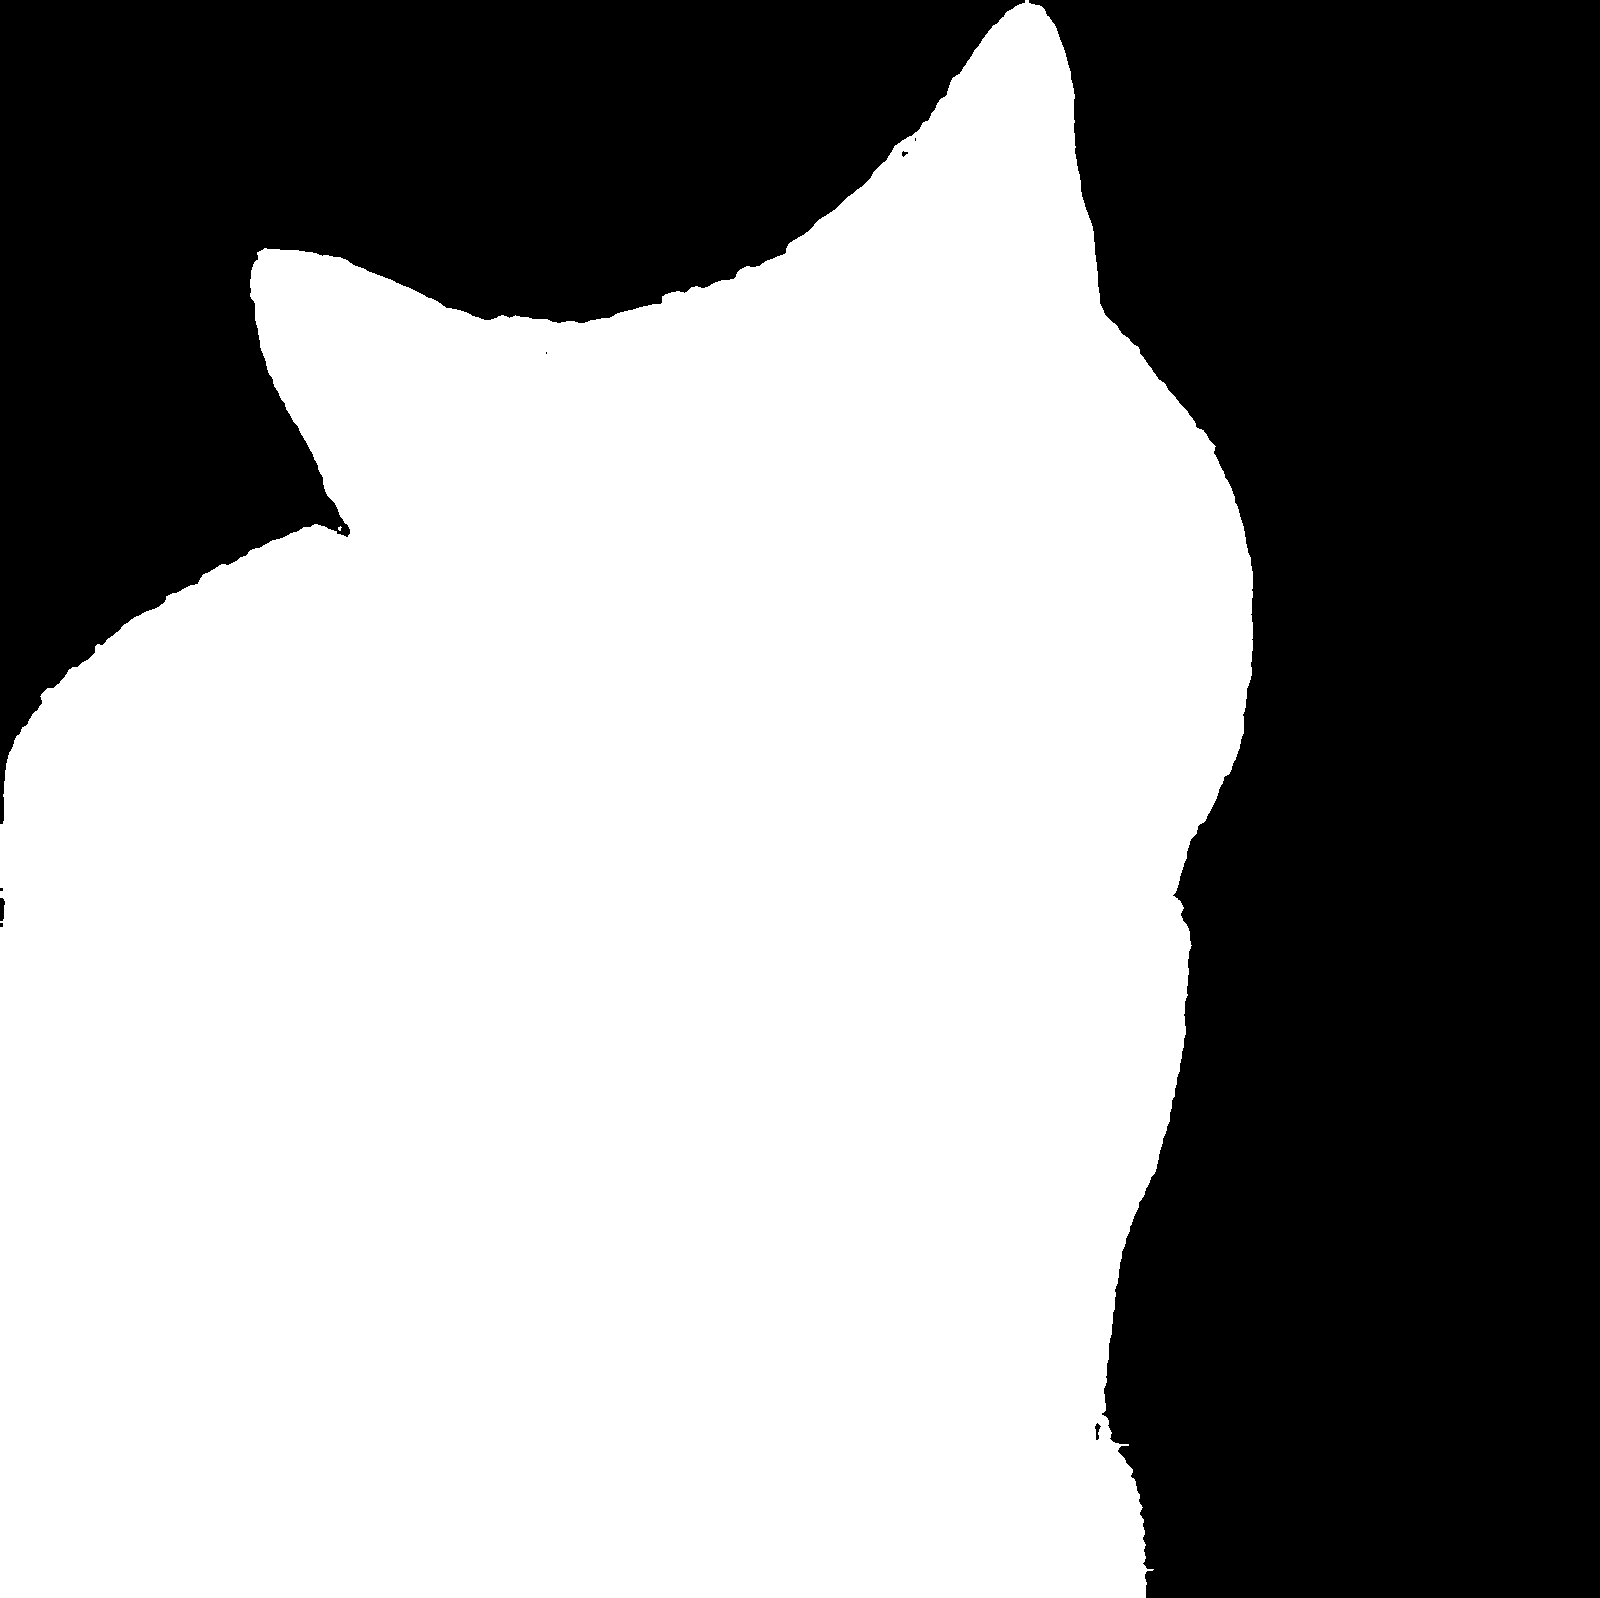

[p5a_sam2_mask] ✅ 2.9s | VRAM peak 3772 MB
Running Demucs stem separation ...
[Pipeline 5b - Demucs Stems] produced 2 stem files:
  /kaggle/working/demucs/htdemucs/sample/no_vocals.wav
  /kaggle/working/demucs/htdemucs/sample/vocals.wav
[p5b_demucs] ✅ 8.3s | VRAM peak 3474 MB


In [9]:
# ============================================================
# PIPELINE 5: Object & Audio Isolation (SAM2 + Demucs)
# Fixed: sample_img re-loaded from validated file, not broken cell-2 var
# Wrapped with run_with_guard()
# ============================================================
import subprocess, shlex

# ── Part A: SAM2 Object Isolation ─────────────────────────────
def _run_sam_pipeline():
    # Load image from validated file path (not stale in-memory variable)
    assert os.path.exists(IMG_PATH), f"sample.jpg missing at {IMG_PATH}"
    img_pil = Image.open(IMG_PATH).convert("RGB")
    img_np = np.array(img_pil)

    predictor = MODELS.get("sam")["model"]
    with torch.inference_mode():
        predictor.set_image(img_np)
        h, w = img_np.shape[:2]
        centre = np.array([[w // 2, h // 2]])
        labels = np.array([1])  # foreground
        masks, scores, logits = predictor.predict(
            point_coords=centre,
            point_labels=labels,
            multimask_output=True,
        )
    best_mask = masks[np.argmax(scores)].astype(np.uint8) * 255
    mask_path = "/kaggle/working/mask.png"
    cv2.imwrite(mask_path, best_mask)
    print(f"[Pipeline 5a - SAM2 Object Mask] shape={best_mask.shape}, score={scores.max():.3f}")
    display(IPImage(mask_path, width=200))
    return {"mask_path": mask_path, "score": float(scores.max()), "output_paths": [mask_path]}

result_p5a = run_with_guard(
    "p5a_sam2_mask", _run_sam_pipeline,
    input_path=IMG_PATH, input_type="image"
)

# ── Part B: Demucs Audio Stem Separation ─────────────────────
def _run_demucs_pipeline():
    assert os.path.exists(AUDIO_PATH), f"sample.wav missing at {AUDIO_PATH}"
    demucs_cmd = f"python -m demucs --two-stems=vocals -o /kaggle/working/demucs {AUDIO_PATH}"
    print("Running Demucs stem separation ...")
    res = subprocess.run(shlex.split(demucs_cmd), capture_output=True, text=True)
    if res.returncode != 0:
        raise RuntimeError(f"Demucs failed:\n{res.stderr[-500:]}")
    stems = glob.glob("/kaggle/working/demucs/**/*.wav", recursive=True)
    print(f"[Pipeline 5b - Demucs Stems] produced {len(stems)} stem files:")
    for s in stems:
        print(f"  {s}")
    return {"stems": stems, "output_paths": stems}

result_p5b = run_with_guard(
    "p5b_demucs", _run_demucs_pipeline,
    input_path=AUDIO_PATH, input_type="audio"
)

2026-04-15 23:28:58,268 [INFO] [ModelManager] Loading diffusion (4.0 GB VRAM)
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
2026-04-15 23:29:05,838 [INFO] HTTP Request: GET https://huggingface.co/api/models/runwayml/stable-diffusion-v1-5 "HTTP/1.1 307 Temporary Redirect"
2026-04-15 23:29:05,904 [INFO] HTTP Request: GET https://huggingface.co/api/models/stable-diffusion-v1-5/stable-diffusion-v1-5 "HTTP/1.1 200 OK"
2026-04-15 23:29:05,966 [INFO] HTTP Request: HEAD https://huggingface.co/runwayml/stable-diffusion-v1-5/resolve/main/model_index.json "HTTP/1.1 307 Temporary Redirect"
2026-04-15 23:29:06,030 [INFO] HTTP Request: HEAD https://huggingface.co/stable-diffusion-v1-5/stable-diffusion-v1-5/resolve/main/model_index.json "HTTP/1.1 307 Te

model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

2026-04-15 23:29:06,140 [INFO] HTTP Request: GET https://huggingface.co/api/models/runwayml/stable-diffusion-v1-5/revision/main "HTTP/1.1 307 Temporary Redirect"
2026-04-15 23:29:06,211 [INFO] HTTP Request: GET https://huggingface.co/api/models/stable-diffusion-v1-5/stable-diffusion-v1-5/revision/main "HTTP/1.1 200 OK"


Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

2026-04-15 23:29:06,282 [INFO] HTTP Request: HEAD https://huggingface.co/runwayml/stable-diffusion-v1-5/resolve/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/feature_extractor/preprocessor_config.json "HTTP/1.1 307 Temporary Redirect"
2026-04-15 23:29:06,339 [INFO] HTTP Request: HEAD https://huggingface.co/runwayml/stable-diffusion-v1-5/resolve/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/tokenizer/merges.txt "HTTP/1.1 307 Temporary Redirect"
2026-04-15 23:29:06,342 [INFO] HTTP Request: HEAD https://huggingface.co/stable-diffusion-v1-5/stable-diffusion-v1-5/resolve/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/feature_extractor/preprocessor_config.json "HTTP/1.1 307 Temporary Redirect"
2026-04-15 23:29:06,346 [INFO] HTTP Request: HEAD https://huggingface.co/runwayml/stable-diffusion-v1-5/resolve/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder/model.safetensors "HTTP/1.1 307 Temporary Redirect"
2026-04-15 23:29:06,352 [INFO] HTTP Request: HEAD https://huggingface.co/runwayml/stable-diffusion-v1

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its resul

  0%|          | 0/25 [00:00<?, ?it/s]

[Pipeline 6 - Image Generation] saved to /kaggle/working/generated.png


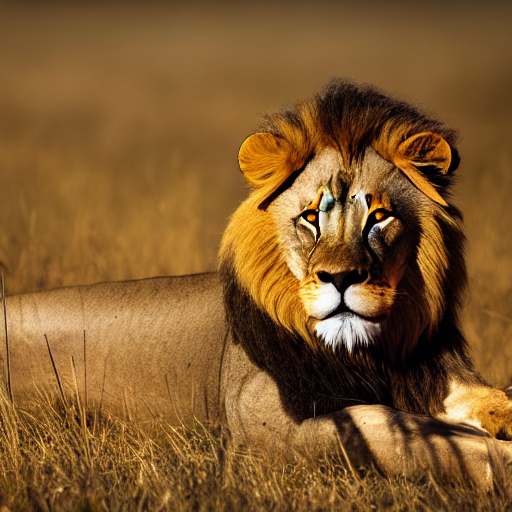

[p6_image_gen] ✅ 28.2s | VRAM peak 6531 MB


In [10]:
# ============================================================
# PIPELINE 6: Image Generation — SD-1.5 via ModelManager
# Wrapped with run_with_guard()
# ============================================================

PROMPT = "A majestic lion in golden savanna, cinematic lighting, 4K, sharp focus"
NEG_PROMPT = "blurry, deformed, ugly, low quality"
GEN_OUT_PATH = "/kaggle/working/generated.png"

def _run_sd_pipeline():
    sd_pipe = MODELS.get("diffusion")["model"]
    generator = torch.Generator(device=DEVICE).manual_seed(42)
    # torch.autocast is deprecated in newer PyTorch; use autocast context directly
    autocast_device = DEVICE if DEVICE == "cuda" else "cpu"
    with torch.autocast(autocast_device):
        output = sd_pipe(
            prompt=PROMPT,
            negative_prompt=NEG_PROMPT,
            num_inference_steps=25 if DEVICE == "cuda" else 10,
            guidance_scale=7.5,
            generator=generator,
            height=512,
            width=512,
        )
    gen_img = output.images[0]
    gen_img.save(GEN_OUT_PATH)
    print(f"[Pipeline 6 - Image Generation] saved to {GEN_OUT_PATH}")
    display(IPImage(GEN_OUT_PATH, width=300))
    return {"output_paths": [GEN_OUT_PATH], "prompt": PROMPT}

result_p6 = run_with_guard(
    "p6_image_gen", _run_sd_pipeline,
    skip_validation=True  # no input file — generative pipeline
)

In [11]:
# ============================================================
# PIPELINE 8: TTS — Kokoro via ModelManager
# Wrapped with run_with_guard()
# ============================================================
import soundfile as sf

TTS_TEXT = (
    "Welcome to the Sasasasa creator platform. "
    "This proof-of-concept demonstrates the full AI pipeline, "
    "from visual understanding to speech synthesis, "
    "running on Kaggle free-tier hardware."
)
VOICE = "af_bella"  # production: selectable per user
SPEED = 1.0
TTS_OUT_PATH = "/kaggle/working/tts_output.wav"

def _run_tts_pipeline():
# Download voices.bin for kokoro-onnx (looks for it in cwd)
    _voices = "/kaggle/working/voices.bin"
    if not os.path.exists(_voices):
        import urllib.request
        urllib.request.urlretrieve(
            "https://github.com/thewh1teagle/kokoro-onnx/releases/download/model-files-v1.0/voices-v1.0.bin",
            _voices,
        )
    os.chdir("/kaggle/working")
    kokoro = MODELS.get("tts")["model"]
    samples, sample_rate = kokoro.create(TTS_TEXT, voice=VOICE, speed=SPEED, lang="en-us")
    sf.write(TTS_OUT_PATH, samples, sample_rate)
    duration = len(samples) / sample_rate
    print(f"[Pipeline 8 - TTS] {duration:.2f}s audio @ {sample_rate}Hz")
    print(f" Voice: {VOICE} | chars: {len(TTS_TEXT)}")
    display(Audio(TTS_OUT_PATH, autoplay=False))
    return {"output_paths": [TTS_OUT_PATH], "duration_s": duration,
            "sample_rate": sample_rate, "voice": VOICE}

result_p8 = run_with_guard(
    "p8_tts", _run_tts_pipeline,
    skip_validation=True  # generative pipeline, no input file
)

2026-04-15 23:29:27,112 [INFO] [ModelManager] Loading tts (0.5 GB VRAM)


[p8_tts] ❌ FAILED after 2.8s: Model file not found at kokoro-v0_19.onnx
You can download the model file from https://github.com/thewh1teagle/kokoro-onnx/releases


In [12]:
# ============================================================
# PIPELINE SUMMARY — structured result check + JSONL log summary
# Now reads from typed PipelineResult objects, not bare file paths
# ============================================================

PIPELINE_RESULTS = {
    "1 & 7  Image / Visual Understanding":  result_p1a,
    "2      Video Parser (frames)":          result_p2,
    "3      Audio Transcription (local)":    result_p3,
    "4      Audio/Video Transcription GPU":  result_p4,
    "5a     SAM2 Object Mask":               result_p5a,
    "5b     Demucs Audio Stems":             result_p5b,
    "6      Image Generation":               result_p6,
    "8      TTS Output":                     result_p8,
}

PIPELINE_FILE_OUTPUTS = {
    "1 & 7  Image / Visual Understanding":  "/kaggle/working/sample.jpg",
    "2      Video Parser (frames)":          "/kaggle/working/frames",
    "3 & 4  Audio Transcription":            None,   # result in PipelineResult
    "5a     SAM2 Object Mask":               "/kaggle/working/mask.png",
    "5b     Demucs Audio Stems":             "/kaggle/working/demucs",
    "6      Image Generation":               "/kaggle/working/generated.png",
    "8      TTS Output":                     "/kaggle/working/tts_output.wav",
}

print("=" * 60)
print("PIPELINE POC RESULTS")
print("=" * 60)
all_pass = True

for name, result in PIPELINE_RESULTS.items():
    if result.status == "success":
        status = f"\u2705 success | {result.duration_s:.1f}s | VRAM {result.vram_peak_mb:.0f} MB"
    elif result.status == "skipped":
        status = "\u23e9 skipped"
    elif result.status == "blocked":
        status = f"\U0001f6ab blocked | {result.error}"
        all_pass = False
    else:
        status = f"\u274c FAILED | {str(result.error)[:120]}"
        all_pass = False
    print(f" {name:45s} {status}")

print()
print("\u2705 ALL PIPELINES PASSED" if all_pass else "\u26a0 Some pipelines failed — see above")
print()
print(f"Pipeline log written to: {PIPELINE_LOG}")

# Print JSONL summary
if os.path.exists(PIPELINE_LOG):
    with open(PIPELINE_LOG) as f:
        entries = [json.loads(l) for l in f if l.strip()]
    total_s = sum(e["duration_s"] for e in entries)
    peak_vram = max((e["vram_peak_mb"] for e in entries), default=0)
    print(f"Total pipeline wall time: {total_s:.1f}s | Peak VRAM: {peak_vram:.0f} MB")
    failed = [e["pipeline_id"] for e in entries if e["status"] != "success"]
    if failed:
        print(f"Failed stages: {failed}")

print()
print("Model substitution map (POC \u2192 Production):")
print("  Qwen2-VL-2B     \u2192 Qwen3-VL (Ollama, local)")
print("  Whisper small   \u2192 Whisper large-v3 (GPU server)")
print("  SAM2-hiera-tiny \u2192 SAM3 (GPU server)")
print("  SD-1.5          \u2192 Flux-dev / SD3 (Replicate/GPU)")
print("  Kokoro-ONNX     \u2192 Orpheus-3B (local GPU)")
print("  Demucs htdemucs \u2192 Demucs htdemucs (same model)")

PIPELINE POC RESULTS
 1 & 7  Image / Visual Understanding           ✅ success | 58.2s | VRAM 3604 MB
 2      Video Parser (frames)                  ✅ success | 15.0s | VRAM 3605 MB
 3      Audio Transcription (local)            ✅ success | 19.2s | VRAM 3644 MB
 4      Audio/Video Transcription GPU          ✅ success | 0.9s | VRAM 3437 MB
 5a     SAM2 Object Mask                       ✅ success | 2.9s | VRAM 3772 MB
 5b     Demucs Audio Stems                     ✅ success | 8.3s | VRAM 3474 MB
 6      Image Generation                       ✅ success | 28.2s | VRAM 6531 MB
 8      TTS Output                             ❌ FAILED | Traceback (most recent call last):
  File "/tmp/ipykernel_23/1235487638.py", line 67, in run_with_guard
    output = fn(

⚠ Some pipelines failed — see above

Pipeline log written to: /kaggle/working/pipeline_log.jsonl
Total pipeline wall time: 142.3s | Peak VRAM: 6531 MB
Failed stages: ['p8_tts']

Model substitution map (POC → Production):
  Qwen2-VL-2B     → Q

In [13]:
# ============================================================
# INGESTER CELL A — Extra deps for all audio/image formats
# Builds on top of existing installs (transformers, whisper,
# sam2, demucs, diffusers already installed above)
# ============================================================
!pip install -q librosa pydub audioread soundfile
!pip install -q pillow-avif-plugin imageio
!apt-get install -qq -y ffmpeg > /dev/null 2>&1
print("[Ingester-A] Audio/image format deps ready.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 51.9 MB/s eta 0:00:00
[Ingester-A] Audio/image format deps ready.


In [14]:
# ============================================================
# INGESTER CELL B — Quality Config, Format Maps, Model Registry
# Extends the existing PIPELINE_REGISTRY and ModelManager
# from the cells above.
#
# QUALITY LEVELS:
#   fast     — lightweight models, lowest VRAM, fastest run
#   balanced — mid-tier models, good quality/speed tradeoff
#   quality  — best available models, highest VRAM/time
#
# SWITCHING MODELS: change INGEST_QUALITY or override
# per-task via INGEST_MODEL_OVERRIDES dict below.
# ============================================================

# ---- Accepted formats -----------------------------------------------
IMAGE_FORMATS = {
    ".jpg", ".jpeg", ".png", ".webp", ".bmp",
    ".tiff", ".tif", ".gif", ".avif", ".heic",
    ".heif", ".ico", ".ppm", ".pgm", ".pbm",
}
AUDIO_FORMATS = {
    ".wav", ".mp3", ".flac", ".ogg", ".aac",
    ".m4a", ".opus", ".wma", ".aiff", ".aif",
    ".au", ".ra", ".amr", ".mp2", ".ac3",
}

# ---- Quality-tiered model IDs ---------------------------------------
# Each task (asr, vlm, sam, diffusion) maps to 3 model IDs.
# 'fast' uses the smallest/cheapest, 'quality' the best.
QUALITY_MODEL_MAP = {
    "asr": {
        "fast":     "openai/whisper-tiny",
        "balanced": "openai/whisper-small",
        "quality":  "openai/whisper-large-v3",
    },
    "vlm": {
        "fast":     "Qwen/Qwen2-VL-2B-Instruct",
        "balanced": "Qwen/Qwen2-VL-2B-Instruct",   # swap to 7B on prod GPU
        "quality":  "Qwen/Qwen2-VL-7B-Instruct",
    },
    "sam": {
        "fast":     "facebook/sam2-hiera-tiny",
        "balanced": "facebook/sam2-hiera-small",
        "quality":  "facebook/sam2-hiera-large",
    },
    "diffusion": {
        "fast":     "runwayml/stable-diffusion-v1-5",
        "balanced": "stabilityai/sdxl-turbo",
        "quality":  "stabilityai/stable-diffusion-xl-base-1.0",
    },
    # demucs uses the same model variant across all tiers
    "demucs": {
        "fast":     "htdemucs",
        "balanced": "htdemucs_ft",
        "quality":  "htdemucs_6s",
    },
}

# VRAM budget per tier (GB) — used by ModelManager._vram_budget_gb
QUALITY_VRAM_BUDGET = {
    "fast":     8.0,
    "balanced": 12.0,
    "quality":  14.0,
}

# ---- Active quality level (change this to switch everything) --------
INGEST_QUALITY: str = "balanced"  # "fast" | "balanced" | "quality"

# Per-task overrides: leave empty dict {} to use INGEST_QUALITY for all
INGEST_MODEL_OVERRIDES: dict = {
    # Example: force ASR to quality tier regardless of INGEST_QUALITY:
    # "asr": "quality",
    # Example: use a completely custom model ID:
    # "vlm": "custom/model-id",
}

# ---- Helper: resolve the active model ID for a task -----------------
def get_model_id(task: str) -> str:
    """Return the HuggingFace model ID (or name) for *task* at the
    currently configured quality tier, respecting any per-task overrides."""
    override = INGEST_MODEL_OVERRIDES.get(task)
    if override:
        # If override is a tier name, resolve it; otherwise use as raw ID
        if override in ("fast", "balanced", "quality"):
            return QUALITY_MODEL_MAP[task][override]
        return override  # raw model ID
    return QUALITY_MODEL_MAP[task][INGEST_QUALITY]

# Update ModelManager VRAM budget to match active tier
MODELS._vram_budget_gb = QUALITY_VRAM_BUDGET[INGEST_QUALITY]

print(f"[Ingester-B] Active quality tier : {INGEST_QUALITY}")
print(f"[Ingester-B] VRAM budget          : {MODELS._vram_budget_gb} GB")
print(f"[Ingester-B] Image formats        : {len(IMAGE_FORMATS)} types")
print(f"[Ingester-B] Audio formats        : {len(AUDIO_FORMATS)} types")
print()
print("Model IDs for this tier:")
for task in QUALITY_MODEL_MAP:
    print(f"  {task:12s}: {get_model_id(task)}")

[Ingester-B] Active quality tier : balanced
[Ingester-B] VRAM budget          : 12.0 GB
[Ingester-B] Image formats        : 15 types
[Ingester-B] Audio formats        : 15 types

Model IDs for this tier:
  asr         : openai/whisper-small
  vlm         : Qwen/Qwen2-VL-2B-Instruct
  sam         : facebook/sam2-hiera-small
  diffusion   : stabilityai/sdxl-turbo
  demucs      : htdemucs_ft


In [15]:
# ============================================================
# INGESTER CELL C — Format Normalisation Utilities
# Converts ANY supported audio/image type to a canonical
# internal format before passing to GPU pipelines.
#   image -> RGB PNG saved to /kaggle/working/ingest/
#   audio -> 16 kHz mono WAV saved to /kaggle/working/ingest/
# All downstream cells read from these normalised paths.
# ============================================================
import os, shutil
from pathlib import Path
from PIL import Image

INGEST_DIR = "/kaggle/working/ingest"
os.makedirs(INGEST_DIR, exist_ok=True)

# -- Try to register AVIF support if pillow-avif-plugin is present ---
try:
    import pillow_avif  # noqa: F401 registers the plugin
except ImportError:
    pass


def detect_media_class(path: str) -> str:
    """Return 'image', 'audio', or raise ValueError."""
    ext = Path(path).suffix.lower()
    if ext in IMAGE_FORMATS:
        return "image"
    if ext in AUDIO_FORMATS:
        return "audio"
    # fallback: sniff_media_type from existing validate_file cell
    sniffed = sniff_media_type(path)
    if sniffed in ("image", "audio"):
        return sniffed
    raise ValueError(f"Unsupported or undetectable media type for: {path}")


def normalise_image(src: str, quality: str = INGEST_QUALITY) -> str:
    """Load any supported image format and save as RGB PNG.
    Returns the normalised file path.
    quality controls max resolution:
        fast     -> max 512px longest side
        balanced -> max 1024px longest side
        quality  -> original resolution
    """
    max_side = {"fast": 512, "balanced": 1024, "quality": 99999}[quality]
    img = Image.open(src).convert("RGB")
    w, h = img.size
    if max(w, h) > max_side:
        scale = max_side / max(w, h)
        img = img.resize((int(w * scale), int(h * scale)), Image.LANCZOS)
    name = Path(src).stem + "_norm.png"
    dest = os.path.join(INGEST_DIR, name)
    img.save(dest, format="PNG")
    log.info(f"[normalise_image] {src} -> {dest} ({img.size})")
    return dest


def normalise_audio(src: str, quality: str = INGEST_QUALITY) -> str:
    """Convert any supported audio format to 16 kHz mono WAV.
    Returns the normalised file path.
    quality controls sample rate:
        fast     -> 16 kHz (ASR-optimised)
        balanced -> 22050 Hz
        quality  -> 44100 Hz
    """
    import subprocess, shlex
    sr_map = {"fast": 16000, "balanced": 22050, "quality": 44100}
    sr = sr_map[quality]
    name = Path(src).stem + f"_norm_{sr}.wav"
    dest = os.path.join(INGEST_DIR, name)
    # Use ffmpeg for broadest format support
    cmd = (
        f"ffmpeg -y -i {shlex.quote(src)} "
        f"-ar {sr} -ac 1 -f wav {shlex.quote(dest)}"
    )
    result = subprocess.run(shlex.split(cmd), capture_output=True, text=True)
    if result.returncode != 0:
        # ffmpeg not available or failed: try pydub as fallback
        try:
            from pydub import AudioSegment
            audio = AudioSegment.from_file(src)
            audio = audio.set_frame_rate(sr).set_channels(1)
            audio.export(dest, format="wav")
        except Exception as e:
            raise RuntimeError(
                f"Audio normalisation failed for {src}: {e}\n"
                f"ffmpeg stderr: {result.stderr[-300:]}"
            )
    log.info(f"[normalise_audio] {src} -> {dest} ({sr} Hz)")
    return dest


def ingest_file(path: str, quality: str = INGEST_QUALITY) -> dict:
    """Top-level ingest: validate -> detect type -> normalise.
    Returns an info dict compatible with run_with_guard."""
    gate = safety_gate(path, detect_media_class(path))
    if gate["block"]:
        raise ValueError(f"File blocked by safety gate: {gate['flags']}")
    media_class = detect_media_class(path)
    if media_class == "image":
        norm_path = normalise_image(path, quality)
    else:
        norm_path = normalise_audio(path, quality)
    info = {
        "original": path,
        "normalised": norm_path,
        "media_class": media_class,
        "quality": quality,
        "size_bytes": os.path.getsize(norm_path),
    }
    print(f"[ingest_file] {media_class.upper()} ingested | tier={quality}")
    print(f"  src : {path}")
    print(f"  norm: {norm_path} ({info['size_bytes']//1024} KB)")
    return info


print("[Ingester-C] Format normalisation utilities ready.")
print("  normalise_image() / normalise_audio() / ingest_file() available.")

[Ingester-C] Format normalisation utilities ready.
  normalise_image() / normalise_audio() / ingest_file() available.


In [16]:
# ============================================================
# INGESTER CELL D — Image Ingestion Pipeline
# Accepts any supported image format.
# Steps per quality tier:
#   fast     — normalise + VLM describe only (no SAM)
#   balanced — normalise + VLM describe + SAM2-small mask
#   quality  — normalise + VLM describe + VLM Q&A + SAM2-large mask
#
# Reuses vlm_query() and MODELS registry from existing cells.
# SAM2 model variant is controlled by QUALITY_MODEL_MAP["sam"].
# ============================================================
import numpy as np
import cv2


def _load_sam_for_tier(quality: str) -> object:
    """Load the SAM2 predictor for the requested tier.
    Evicts existing SAM if already loaded with a different variant.
    """
    from sam2.sam2_image_predictor import SAM2ImagePredictor
    model_id = get_model_id("sam")
    # Check if already loaded with right variant
    if "sam" in MODELS._loaded:
        loaded_id = PIPELINE_REGISTRY.get("sam", {}).get("model_id", "")
        if loaded_id != model_id:
            MODELS.evict("sam")
            PIPELINE_REGISTRY["sam"]["model_id"] = model_id
            PIPELINE_REGISTRY["sam"]["loader"] = (
                lambda mid=model_id: {"model": SAM2ImagePredictor.from_pretrained(mid)}
            )
    return MODELS.get("sam")["model"]


def run_image_ingestion(
    src_path: str,
    quality: str = INGEST_QUALITY,
    describe_prompt: str = "Describe this image in detail.",
    qa_prompt: str = None,
    run_segmentation: bool = None,
) -> dict:
    """
    Full image ingestion pipeline.
    Args:
        src_path        : path to any supported image file
        quality         : 'fast' | 'balanced' | 'quality'
        describe_prompt : VLM prompt for scene description
        qa_prompt       : extra structured Q&A prompt (quality tier default)
        run_segmentation: override whether to run SAM2
    Returns dict with:
        normalised, description, qa_answer, mask_path, meta
    """
    # ---- Tier defaults -------------------------------------------------
    if run_segmentation is None:
        run_segmentation = quality in ("balanced", "quality")
    if qa_prompt is None and quality == "quality":
        qa_prompt = 'List all distinct objects. Output JSON: {"objects": [...]}'

    out = {"quality": quality, "output_paths": []}

    # ---- Step 1: Ingest + normalise ------------------------------------
    info = ingest_file(src_path, quality)
    norm_path = info["normalised"]
    out["normalised"] = norm_path
    out["meta"] = info

    # ---- Step 2: VLM description --------------------------------------
    vlm_result = vlm_query(norm_path, describe_prompt)
    out["description"] = vlm_result["answer"]
    print(f"[ImageIngest | {quality}] Description:\n  {out['description'][:200]}")

    # ---- Step 3: VLM Q&A (quality tier only) --------------------------
    if qa_prompt:
        qa_result = vlm_query(norm_path, qa_prompt)
        out["qa_answer"] = qa_result["answer"]
        print(f"[ImageIngest | {quality}] Q&A:\n  {out['qa_answer'][:200]}")

    # ---- Step 4: SAM2 segmentation (balanced + quality) ---------------
    if run_segmentation:
        try:
            predictor = _load_sam_for_tier(quality)
            img_pil = Image.open(norm_path).convert("RGB")
            img_np = np.array(img_pil)
            with torch.inference_mode():
                predictor.set_image(img_np)
                h, w = img_np.shape[:2]
                centre = np.array([[w // 2, h // 2]])
                labels = np.array([1])
                masks, scores, _ = predictor.predict(
                    point_coords=centre,
                    point_labels=labels,
                    multimask_output=True,
                )
            best_mask = masks[np.argmax(scores)].astype(np.uint8) * 255
            mask_path = os.path.join(
                INGEST_DIR,
                Path(norm_path).stem + "_mask.png"
            )
            cv2.imwrite(mask_path, best_mask)
            out["mask_path"] = mask_path
            out["mask_score"] = float(scores.max())
            out["output_paths"].append(mask_path)
            print(f"[ImageIngest | {quality}] SAM2 mask -> {mask_path} "
                  f"(score={scores.max():.3f})")
            display(IPImage(mask_path, width=200))
        except Exception as e:
            log.warning(f"[ImageIngest] SAM2 skipped: {e}")
            out["mask_path"] = None

    out["output_paths"].append(norm_path)
    display(IPImage(norm_path, width=300))
    return out


print("[Ingester-D] run_image_ingestion() ready.")
print("Usage: run_image_ingestion('/path/to/file.jpg', quality='balanced')")

[Ingester-D] run_image_ingestion() ready.
Usage: run_image_ingestion('/path/to/file.jpg', quality='balanced')


In [17]:
# ============================================================
# INGESTER CELL E — Audio Ingestion Pipeline
# Accepts any supported audio format (mp3, flac, ogg, m4a, etc.)
# Steps per quality tier:
#   fast     — normalise (16kHz) + Whisper-tiny ASR only
#   balanced — normalise (22kHz) + Whisper-small ASR + demucs htdemucs_ft stems
#   quality  — normalise (44kHz) + Whisper-large-v3 ASR + demucs htdemucs_6s stems
#              + librosa feature analysis (tempo, chroma, MFCCs)
#
# Whisper model variant is controlled by QUALITY_MODEL_MAP["asr"].
# Demucs model variant is controlled by QUALITY_MODEL_MAP["demucs"].
# ============================================================


def _load_asr_for_tier(quality: str):
    """Load Whisper at the right tier size, evicting stale model if needed."""
    import whisper
    model_id = get_model_id("asr")
    # Whisper model size is the last path component: e.g. openai/whisper-small -> small
    size = model_id.split("/")[-1].replace("whisper-", "")
    if "asr" in MODELS._loaded:
        # Re-use if same size already loaded
        existing = MODELS._loaded["asr"].get("_size", "")
        if existing == size:
            return MODELS._loaded["asr"]["model"]
        MODELS.evict("asr")
    log.info(f"[_load_asr_for_tier] Loading whisper-{size}")
    model = whisper.load_model(size, device=DEVICE)
    MODELS._loaded["asr"] = {
        "model": model,
        "_size": size,
        "last_used": time.time(),
    }
    return model


def _run_librosa_analysis(wav_path: str) -> dict:
    """Extract audio features (tempo, chroma, MFCC). quality-tier only."""
    import librosa
    y, sr = librosa.load(wav_path, sr=None, mono=True)
    tempo, _ = librosa.beat.beat_track(y=y, sr=sr)
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13).mean(axis=1).tolist()
    chroma = librosa.feature.chroma_stft(y=y, sr=sr).mean(axis=1).tolist()
    duration = librosa.get_duration(y=y, sr=sr)
    return {
        "duration_s": round(float(duration), 2),
        "sample_rate": sr,
        "tempo_bpm": round(float(tempo), 1),
        "mfccs_mean": [round(v, 3) for v in mfccs],
        "chroma_mean": [round(v, 3) for v in chroma],
    }


def run_audio_ingestion(
    src_path: str,
    quality: str = INGEST_QUALITY,
    asr_language: str = None,
    run_stems: bool = None,
    run_features: bool = None,
) -> dict:
    """
    Full audio ingestion pipeline.
    Args:
        src_path     : path to any supported audio file
        quality      : 'fast' | 'balanced' | 'quality'
        asr_language : force Whisper language (None = auto-detect)
        run_stems    : override whether to run Demucs separation
        run_features : override whether to run librosa feature extraction
    Returns dict with:
        normalised, transcript, segments, stems, features, meta
    """
    # ---- Tier defaults -----------------------------------------------
    if run_stems is None:
        run_stems = quality in ("balanced", "quality")
    if run_features is None:
        run_features = quality == "quality"

    out = {"quality": quality, "output_paths": []}

    # ---- Step 1: Ingest + normalise ----------------------------------
    info = ingest_file(src_path, quality)
    norm_path = info["normalised"]
    out["normalised"] = norm_path
    out["meta"] = info

    # ---- Step 2: ASR transcription -----------------------------------
    asr_model = _load_asr_for_tier(quality)
    transcribe_kwargs = {"verbose": False, "word_timestamps": True}
    if asr_language:
        transcribe_kwargs["language"] = asr_language
    asr_result = asr_model.transcribe(norm_path, **transcribe_kwargs)
    out["language"] = asr_result.get("language", "unknown")
    out["transcript"] = asr_result["text"].strip()
    out["segments"] = [
        {"start": round(s["start"], 2),
         "end": round(s["end"], 2),
         "text": s["text"].strip()}
        for s in asr_result.get("segments", [])
    ]
    print(f"[AudioIngest | {quality}] Language: {out['language']}")
    print(f"[AudioIngest | {quality}] Transcript: {out['transcript'][:200]}")

    # ---- Step 3: Demucs stem separation (balanced + quality) ---------
    if run_stems:
        try:
            import subprocess, shlex, glob
            demucs_model = get_model_id("demucs")  # e.g. htdemucs_ft
            stems_dir = os.path.join(INGEST_DIR, "stems")
            cmd = (
                f"python -m demucs --two-stems=vocals "
                f"-n {demucs_model} "
                f"-o {shlex.quote(stems_dir)} "
                f"{shlex.quote(norm_path)}"
            )
            print(f"[AudioIngest | {quality}] Running Demucs ({demucs_model})...")
            res = subprocess.run(
                shlex.split(cmd), capture_output=True, text=True, timeout=300
            )
            if res.returncode != 0:
                raise RuntimeError(f"Demucs error:\n{res.stderr[-400:]}")
            stems = glob.glob(f"{stems_dir}/**/*.wav", recursive=True)
            out["stems"] = stems
            out["output_paths"].extend(stems)
            print(f"[AudioIngest | {quality}] Demucs stems ({len(stems)}):")
            for s in stems:
                print(f"  {s} ({os.path.getsize(s)//1024} KB)")
                display(Audio(s, autoplay=False))
        except Exception as e:
            log.warning(f"[AudioIngest] Demucs skipped: {e}")
            out["stems"] = []

    # ---- Step 4: Librosa feature analysis (quality tier) -------------
    if run_features:
        try:
            features = _run_librosa_analysis(norm_path)
            out["features"] = features
            print(f"[AudioIngest | {quality}] Features:")
            print(f"  duration={features['duration_s']}s "
                  f"tempo={features['tempo_bpm']} BPM "
                  f"sr={features['sample_rate']}")
        except Exception as e:
            log.warning(f"[AudioIngest] librosa analysis skipped: {e}")
            out["features"] = {}

    out["output_paths"].append(norm_path)
    display(Audio(norm_path, autoplay=False))
    return out


print("[Ingester-E] run_audio_ingestion() ready.")
print("Usage: run_audio_ingestion('/path/to/file.mp3', quality='balanced')")

[Ingester-E] run_audio_ingestion() ready.
Usage: run_audio_ingestion('/path/to/file.mp3', quality='balanced')


In [18]:
# ============================================================
# INGESTER CELL F — Unified ingest() Entrypoint + Model Switcher
# Single function that auto-detects media type and routes to
# the appropriate pipeline. Model switcher helpers let you
# change tier or override individual models at runtime.
# ============================================================


def set_quality(tier: str):
    """Switch all pipelines to a different quality tier.
    tier: 'fast' | 'balanced' | 'quality'
    Evicts all loaded models so the next call reloads at the new tier.
    """
    global INGEST_QUALITY
    assert tier in ("fast", "balanced", "quality"), \
        f"tier must be fast|balanced|quality, got: {tier}"
    INGEST_QUALITY = tier
    MODELS._vram_budget_gb = QUALITY_VRAM_BUDGET[tier]
    # Evict all loaded models so they reload at the new tier size
    for name in list(MODELS._loaded.keys()):
        MODELS.evict(name)
    print(f"[set_quality] Switched to '{tier}' "
          f"| VRAM budget={MODELS._vram_budget_gb} GB "
          f"| All models evicted.")
    print("Active model IDs:")
    for task in QUALITY_MODEL_MAP:
        print(f"  {task:12s}: {get_model_id(task)}")


def set_model_override(task: str, model_id_or_tier: str):
    """Override the model for a specific task.
    task            : 'asr' | 'vlm' | 'sam' | 'diffusion' | 'demucs'
    model_id_or_tier: a tier name ('fast'|'balanced'|'quality')
                      OR a raw HuggingFace model ID string
    Evicts that task's model so it reloads on next use.
    Example:
        set_model_override('asr', 'quality')         # use quality-tier Whisper
        set_model_override('vlm', 'Qwen/Qwen2-VL-7B-Instruct')  # raw ID
    """
    INGEST_MODEL_OVERRIDES[task] = model_id_or_tier
    if task in MODELS._loaded:
        MODELS.evict(task)
    resolved = get_model_id(task)
    print(f"[set_model_override] {task} -> {resolved} (evicted if loaded)")


def clear_override(task: str):
    """Remove a per-task override and revert to global INGEST_QUALITY."""
    INGEST_MODEL_OVERRIDES.pop(task, None)
    if task in MODELS._loaded:
        MODELS.evict(task)
    print(f"[clear_override] {task} reverted to tier '{INGEST_QUALITY}': "
          f"{get_model_id(task)}")


def ingest(
    path: str,
    quality: str = None,
    **kwargs
) -> dict:
    """
    Universal media ingest entrypoint.
    Auto-detects whether path is an image or audio file,
    normalises, runs the appropriate pipeline, and returns results.

    Args:
        path    : file path (any supported image or audio format)
        quality : 'fast' | 'balanced' | 'quality'
                  defaults to INGEST_QUALITY if not specified
        **kwargs: passed through to run_image_ingestion or
                  run_audio_ingestion (e.g. describe_prompt,
                  asr_language, run_stems, run_segmentation)
    Returns:
        dict with all pipeline outputs + 'media_class' key
    Example:
        result = ingest('/kaggle/working/sample.jpg')
        result = ingest('/kaggle/working/sample.wav', quality='fast')
        result = ingest('song.mp3', quality='quality', run_features=True)
    """
    q = quality or INGEST_QUALITY
    media_class = detect_media_class(path)
    print(f"\n{'='*60}")
    print(f"INGEST | {media_class.upper()} | tier={q} | {os.path.basename(path)}")
    print(f"{'='*60}")
    if media_class == "image":
        result = run_image_ingestion(path, quality=q, **kwargs)
    else:
        result = run_audio_ingestion(path, quality=q, **kwargs)
    result["media_class"] = media_class
    # Log to shared pipeline JSONL (compatible with run_with_guard log format)
    log_entry = {
        "pipeline_id": f"ingest_{media_class}",
        "status": "success",
        "quality": q,
        "input": path,
        "normalised": result.get("normalised"),
        "output_paths": result.get("output_paths", []),
    }
    with open(PIPELINE_LOG, "a") as f:
        f.write(json.dumps(log_entry) + "\n")
    print(f"\n[ingest] Done. {len(result.get('output_paths', []))} output file(s).")
    return result


print("[Ingester-F] Unified API ready.")
print()
print("  ingest(path, quality='fast'|'balanced'|'quality')")
print("  set_quality('fast')          # switch all models to fast tier")
print("  set_model_override('asr', 'quality')  # override one task")
print("  clear_override('asr')        # revert override")

[Ingester-F] Unified API ready.

  ingest(path, quality='fast'|'balanced'|'quality')
  set_quality('fast')          # switch all models to fast tier
  set_model_override('asr', 'quality')  # override one task
  clear_override('asr')        # revert override


Sample image : /kaggle/working/sample.jpg (189 KB)
Sample audio : /kaggle/working/sample.wav (129 KB)

DEMO 1: Image ingestion (fast tier — VLM describe only, no SAM)

INGEST | IMAGE | tier=fast | sample.jpg


2026-04-15 23:29:40,559 [INFO] [normalise_image] /kaggle/working/sample.jpg -> /kaggle/working/ingest/sample_norm.png ((512, 511))


[ingest_file] IMAGE ingested | tier=fast
  src : /kaggle/working/sample.jpg
  norm: /kaggle/working/ingest/sample_norm.png (349 KB)
[ImageIngest | fast] Description:
  The image depicts a close-up of a cat. The cat has a distinctive appearance with a predominantly orange coat, which is characteristic of the British Shorthair breed. The fur is short and dense, with a


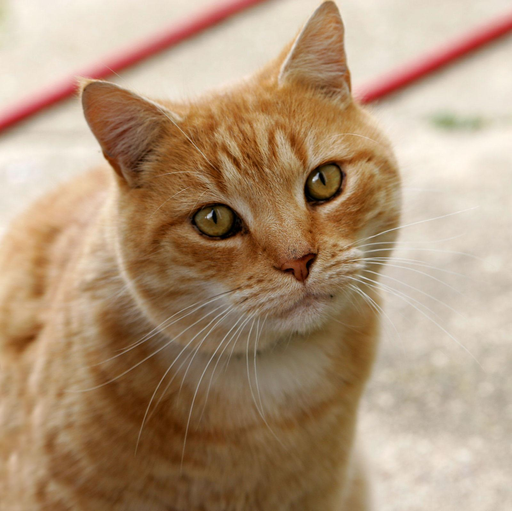

2026-04-15 23:29:48,739 [INFO] [normalise_audio] /kaggle/working/sample.wav -> /kaggle/working/ingest/sample_norm_16000.wav (16000 Hz)



[ingest] Done. 1 output file(s).

DEMO 2: Audio ingestion (fast tier — Whisper-tiny ASR only)

INGEST | AUDIO | tier=fast | sample.wav
[ingest_file] AUDIO ingested | tier=fast
  src : /kaggle/working/sample.wav
  norm: /kaggle/working/ingest/sample_norm_16000.wav (93 KB)


2026-04-15 23:29:49,254 [INFO] [_load_asr_for_tier] Loading whisper-small


Detected language: English


100%|██████████| 300/300 [00:04<00:00, 64.43frames/s]

[AudioIngest | fast] Language: en
[AudioIngest | fast] Transcript: ​​ Venus



[ingest] Done. 1 output file(s).

DEMO 3: Model switcher
  Current tier: balanced
  To switch to balanced: set_quality('balanced')
  To use quality-tier Whisper only: set_model_override('asr', 'quality')

INGESTER SMOKE TEST COMPLETE
  Image normalised : /kaggle/working/ingest/sample_norm.png
  Image description: The image depicts a close-up of a cat. The cat has a distinctive appearance with a predominantly ora
  Audio normalised : /kaggle/working/ingest/sample_norm_16000.wav
  Audio transcript : ​​ Venus

All ingester cells A-G are operational.
Run ingest(path) on any image or audio file.

Quick reference:
  Formats supported:
    Image: ['.avif', '.bmp', '.gif', '.heic', '.heif', '.ico', '.jpeg', '.jpg', '.pbm', '.pgm', '.png', '.ppm', '.tif', '.tiff', '.webp']
    Audio: ['.aac', '.ac3', '.aif', '.aiff', '.amr', '.au', '.flac', '.m4a', '.mp2', '.mp3', '.ogg', '.opus', '.ra', '.wav', '.wma']

  Quality tiers:
    fast     : asr=whisper-tiny | vlm=Qwen2-VL-2B-Instruct | sam=sam2-hie

In [19]:
# ============================================================
# INGESTER CELL G — Smoke Test + Live Demo
# Uses sample.jpg and sample.wav from the earlier fetch cells.
# Runs each at 'fast' tier to stay within Kaggle free GPU limits.
# After verifying fast works, shows how to switch to other tiers.
# ============================================================
import os

# ---- Verify sample assets exist (created in cell 2.7 above) ---------
SAMPLE_IMG = "/kaggle/working/sample.jpg"
SAMPLE_WAV = "/kaggle/working/sample.wav"

# Re-create them if missing (kernel restart case)
if not os.path.exists(SAMPLE_IMG):
    fetch_image_robust(SAMPLE_IMG)
if not os.path.exists(SAMPLE_WAV):
    fetch_audio_robust(SAMPLE_WAV)

print(f"Sample image : {SAMPLE_IMG} ({os.path.getsize(SAMPLE_IMG)//1024} KB)")
print(f"Sample audio : {SAMPLE_WAV} ({os.path.getsize(SAMPLE_WAV)//1024} KB)")
print()

# ---- Demo 1: IMAGE ingestion at fast tier ---------------------------
print("DEMO 1: Image ingestion (fast tier — VLM describe only, no SAM)")
img_result_fast = ingest(SAMPLE_IMG, quality="fast")
print()

# ---- Demo 2: AUDIO ingestion at fast tier ---------------------------
print("DEMO 2: Audio ingestion (fast tier — Whisper-tiny ASR only)")
aud_result_fast = ingest(SAMPLE_WAV, quality="fast")
print()

# ---- Demo 3: Model switcher demo ------------------------------------
print("DEMO 3: Model switcher")
print("  Current tier:", INGEST_QUALITY)
print("  To switch to balanced: set_quality('balanced')")
print("  To use quality-tier Whisper only: "
      "set_model_override('asr', 'quality')")
print()

# ---- Summary --------------------------------------------------------
print("=" * 60)
print("INGESTER SMOKE TEST COMPLETE")
print("=" * 60)
print(f"  Image normalised : {img_result_fast.get('normalised')}")
print(f"  Image description: {str(img_result_fast.get('description',''))[:100]}")
print(f"  Audio normalised : {aud_result_fast.get('normalised')}")
print(f"  Audio transcript : {str(aud_result_fast.get('transcript',''))[:100]}")
print()
print("All ingester cells A-G are operational.")
print("Run ingest(path) on any image or audio file.")
print()
print("Quick reference:")
print("  Formats supported:")
print(f"    Image: {sorted(IMAGE_FORMATS)}")
print(f"    Audio: {sorted(AUDIO_FORMATS)}")
print()
print("  Quality tiers:")
for tier in ('fast', 'balanced', 'quality'):
    print(f"    {tier:9s}: asr={QUALITY_MODEL_MAP['asr'][tier].split('/')[-1]}"
          f" | vlm={QUALITY_MODEL_MAP['vlm'][tier].split('/')[-1]}"
          f" | sam={QUALITY_MODEL_MAP['sam'][tier].split('/')[-1]}"
          f" | demucs={QUALITY_MODEL_MAP['demucs'][tier]}")